In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
########################################
# 1. PARAMETERS
########################################

tau     = 0.9       # fractional order (0 < tau <= 1)

# Host parameters
lam     = 0.5       # λ^τ  : host recruitment
beta0   = 3e-4      # β_0^τ: susceptible infection rate
beta1   = 2e-4      # β_1^τ: vaccinated infection rate
mu      = 0.05      # μ^τ  : host natural death rate
nu      = 0.10      # ν^τ  : vaccination rate
delta   = 0.08      # δ^τ  : disease progression
alpha0  = 0.02      # α_0^τ
alpha1  = 0.03      # α_1^τ
rho     = 0.07      # ρ^τ  : P → R_C

# Vector parameters
lam_n   = 0.40      # λ_n^τ
beta2   = 4e-4      # β_2^τ
eta1    = 0.50      # η_1^τ
eta2    = 0.30      # η_2^τ
eta3    = 0.20      # η_3^τ
mu_An   = 0.06      # μ_An^τ
sigma_n = 0.04      # σ_n^τ
mu_A    = 0.05      # μ_A^τ

# Initial conditions  [S, V, P, U, R_C, A_sn, A_in, A_sa, A_ia]
Y0_np = np.array([1000., 200., 50., 30., 10.,
                   500.,  20., 300., 15.], dtype=np.float32)

VAR_NAMES = ["S", "V", "P", "U", "R_C", "A_sn", "A_in", "A_sa", "A_ia"]

In [3]:
########################################
# 2. ABM REFERENCE SOLUTION (ground truth)
########################################

def rhs_np(y, p=None):
    S, V, P, U, RC, Asn, Ain, Asa, Aia = np.maximum(y, 0.0)
    inf_h   = beta0 * (Ain + Aia)
    inf_v   = beta1 * (Ain + Aia)
    inf_vec = beta2 * (eta1*P + eta2*U + eta3*RC)
    dS   = lam  - inf_h*S  - mu*S - nu*S
    dV   = nu*S - inf_v*V  - mu*V
    dP   = inf_h*S + inf_v*V - (mu + delta + alpha0 + rho)*P
    dU   = delta*P - (mu + alpha1)*U
    dRC  = rho*P   - mu*RC
    dAsn = lam_n - inf_vec*Asn - mu_An*Asn - sigma_n*Asn
    dAin = inf_vec*Asn - mu_An*Ain - sigma_n*Ain
    dAsa = sigma_n*Asn - inf_vec*Asa - mu_A*Asa
    dAia = sigma_n*Ain + inf_vec*Asa - mu_A*Aia
    return np.array([dS, dV, dP, dU, dRC, dAsn, dAin, dAsa, dAia])


def abm_solve(y0, t_arr):
    """Adams-Bashforth-Moulton for Caputo FDE (Diethelm et al. 2002)."""
    N     = len(t_arr) - 1
    dh    = t_arr[1] - t_arr[0]
    g1    = Gamma(tau + 1)
    g2    = Gamma(tau + 2)
    Y     = np.zeros((N + 1, len(y0)))
    F     = np.zeros((N + 1, len(y0)))
    Y[0]  = y0
    F[0]  = rhs_np(y0)
    for k in range(N):
        j   = np.arange(k + 1, dtype=float)
        b   = dh**tau / g1 * ((k - j + 1)**tau - (k - j)**tau)
        Y_P = y0 + b @ F[:k+1]
        F_P = rhs_np(Y_P)
        jj  = np.arange(k + 1, dtype=float)
        a   = np.where(
            jj == 0,
            dh**tau / g2 * (k**(tau+1) - (k - tau)*(k+1)**tau),
            dh**tau / g2 * ((k - jj + 2)**(tau+1)
                            + (k - jj)**(tau+1)
                            - 2*(k - jj + 1)**(tau+1))
        )
        Y[k+1] = y0 + dh**tau / g2 * F_P + a @ F[:k+1]
        Y[k+1] = np.maximum(Y[k+1], 0.0)
        F[k+1] = rhs_np(Y[k+1])
    return Y


t_start  = 0
t_end    = 50
n_points = 30

t_abm     = np.linspace(t_start, t_end, n_points)
Y_abm     = abm_solve(Y0_np, t_abm)       

In [4]:
########################################
# 3. TRAINING POINTS & DATA
########################################

t_train = torch.tensor(t_abm, dtype=torch.float32).view(-1, 1).to(device)
t_train.requires_grad = True

Y_train = torch.tensor(Y_abm, dtype=torch.float32).to(device)   # (n_points, 9)


In [5]:
########################################
# 4. PINN MODEL
########################################

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 9)       
        )

    def forward(self, t):
        return torch.nn.functional.softplus(self.net(t))

model = PINN().to(device)

In [6]:
########################################
# 5. GRÜNWALD-LETNIKOV CAPUTO DERIVATIVE
#    Approximates  C_D_h^tau  on the training grid
########################################

def gl_weights_tensor(tau, M):
    """
    Grünwald-Letnikov weights  w_0 … w_M
      w_0 = 1,  w_j = w_{j-1} * (j - 1 - tau) / j
    """
    w = torch.zeros(M + 1, dtype=torch.float32, device=device)
    w[0] = 1.0
    for j in range(1, M + 1):
        w[j] = w[j - 1] * (j - 1.0 - tau) / j
    return w


def caputo_derivative(Y_pred, dh, tau):
    """
    Y_pred : (N, 9)  network outputs on uniform grid
    returns : (N, 9)  Caputo derivatives at every grid point
    """
    N = Y_pred.shape[0]
    W = gl_weights_tensor(tau, N - 1)
    deriv = torch.zeros_like(Y_pred)
    for k in range(N):
        idx = torch.arange(k + 1, device=device)
        w_k = W[:k + 1].unsqueeze(1)       # (k+1, 1)
        y_k = Y_pred[k - idx, :]           # (k+1, 9)
        deriv[k] = (w_k * y_k).sum(dim=0) / (dh ** tau)
    return deriv


In [7]:
########################################
# 6. RIGHT-HAND SIDE  f(Y)
########################################

def rhs_tensor(Y):
    """Y : (N, 9)  →  F : (N, 9)"""
    Y = torch.clamp(Y, min=0.0)
    S, V, P, U, RC, Asn, Ain, Asa, Aia = [Y[:, i] for i in range(9)]

    inf_h   = beta0 * (Ain + Aia)
    inf_v   = beta1 * (Ain + Aia)
    inf_vec = beta2 * (eta1*P + eta2*U + eta3*RC)

    dS   = lam  - inf_h*S  - mu*S - nu*S
    dV   = nu*S - inf_v*V  - mu*V
    dP   = inf_h*S + inf_v*V - (mu + delta + alpha0 + rho)*P
    dU   = delta*P - (mu + alpha1)*U
    dRC  = rho*P   - mu*RC
    dAsn = lam_n - inf_vec*Asn - mu_An*Asn - sigma_n*Asn
    dAin = inf_vec*Asn - mu_An*Ain - sigma_n*Ain
    dAsa = sigma_n*Asn - inf_vec*Asa - mu_A*Asa
    dAia = sigma_n*Ain + inf_vec*Asa - mu_A*Aia

    return torch.stack([dS, dV, dP, dU, dRC, dAsn, dAin, dAsa, dAia], dim=1)


In [8]:
########################################
# 12. PREDICTION
########################################

n_testpoints = 200
t_test = torch.linspace(t_start, t_end, n_testpoints).view(-1, 1).to(device)

with torch.no_grad():
    Y_pred_np = model(t_test).cpu().numpy()

t_np = t_test.cpu().numpy().flatten()

# Unpack predictions
S_p, V_p, P_p, U_p, RC_p, Asn_p, Ain_p, Asa_p, Aia_p = [
    Y_pred_np[:, i] for i in range(9)
]

# ABM reference on same dense grid for comparison
Y_ref = abm_solve(Y0_np, np.linspace(t_start, t_end, n_testpoints))
S_r, V_r, P_r, U_r, RC_r, Asn_r, Ain_r, Asa_r, Aia_r = [
    Y_ref[:, i] for i in range(9)
]




In [9]:

########################################
# 7. PHYSICS LOSS
#    Residual:  C_D_h^tau Y  =  f(Y)
########################################

def physics_loss():
    Y_pred = model(t_train)                              # (N, 9)
    dh     = float((t_end - t_start) / (n_points - 1))
    D_Y    = caputo_derivative(Y_pred, dh, tau)          # (N, 9)
    F      = rhs_tensor(Y_pred)                          # (N, 9)
    residual = D_Y - F
    return torch.mean(torch.square(residual))

########################################
# 8. INITIAL CONDITION LOSS
########################################

def initial_condition_loss():
    t0      = torch.tensor([[0.0]], device=device)
    pred0   = model(t0).squeeze(0)                       
    Y0_t    = torch.tensor(Y0_np, device=device)
    scale   = Y0_t.clamp(min=1.0)
    return torch.mean(torch.square((pred0 - Y0_t) / scale))

########################################
# 9. DATA LOSS
########################################

def data_loss():
    Y_pred = model(t_train)                              
    scale  = Y_train.clamp(min=1.0)
    return torch.mean(torch.square((Y_pred - Y_train) / scale))

########################################
# 10. OPTIMIZER
########################################

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    mode="exp_range",
    base_lr=1e-5,
    max_lr=1e-3,
    step_size_up=100,
    gamma=0.85
)

########################################
# 11. TRAINING LOOP
########################################

epochs       = 50000
loss_history = []
loss_phys_h  = []
loss_ic_h    = []
loss_data_h  = []

for epoch in range(epochs):

    optimizer.zero_grad()

    loss_pde  = physics_loss()
    loss_ic   = initial_condition_loss()
    loss_dat  = data_loss()

    loss = loss_pde + 10.0 * loss_ic + loss_dat

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())
    loss_phys_h.append(loss_pde.item())
    loss_ic_h.append(loss_ic.item())
    loss_data_h.append(loss_dat.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:>6} | Total: {loss.item():.4e} | "
              f"PDE: {loss_pde.item():.4e} | "
              f"IC: {loss_ic.item():.4e} | "
              f"Data: {loss_dat.item():.4e}")

Epoch      0 | Total: 1.0579e+01 | PDE: 3.6990e-02 | IC: 9.5712e-01 | Data: 9.7103e-01
Epoch   1000 | Total: 9.8325e+00 | PDE: 6.5702e-02 | IC: 8.8300e-01 | Data: 9.3686e-01
Epoch   2000 | Total: 9.2937e+00 | PDE: 1.2520e-01 | IC: 8.2725e-01 | Data: 8.9599e-01
Epoch   3000 | Total: 8.9721e+00 | PDE: 1.9735e-01 | IC: 7.9066e-01 | Data: 8.6823e-01
Epoch   4000 | Total: 8.7323e+00 | PDE: 2.7607e-01 | IC: 7.6103e-01 | Data: 8.4592e-01
Epoch   5000 | Total: 8.5392e+00 | PDE: 3.5529e-01 | IC: 7.3565e-01 | Data: 8.2739e-01
Epoch   6000 | Total: 8.3856e+00 | PDE: 4.2910e-01 | IC: 7.1443e-01 | Data: 8.1225e-01
Epoch   7000 | Total: 8.2530e+00 | PDE: 4.5894e-01 | IC: 6.9626e-01 | Data: 8.3153e-01
Epoch   8000 | Total: 8.1165e+00 | PDE: 4.9561e-01 | IC: 6.7760e-01 | Data: 8.4494e-01
Epoch   9000 | Total: 7.9859e+00 | PDE: 5.3255e-01 | IC: 6.6073e-01 | Data: 8.4608e-01
Epoch  10000 | Total: 7.8949e+00 | PDE: 5.9349e-01 | IC: 6.4585e-01 | Data: 8.4289e-01
Epoch  11000 | Total: 7.8252e+00 | PDE: 6.5

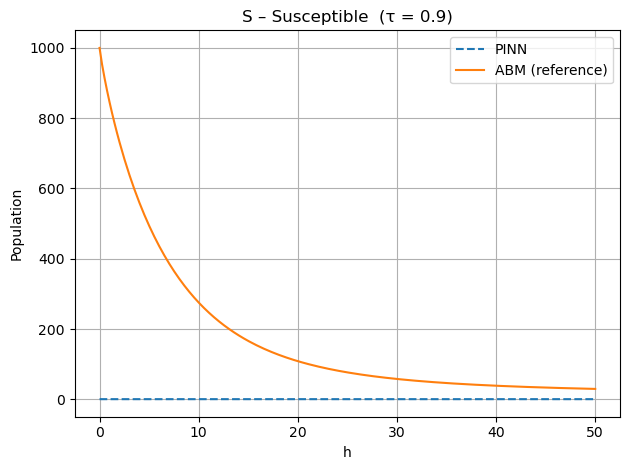

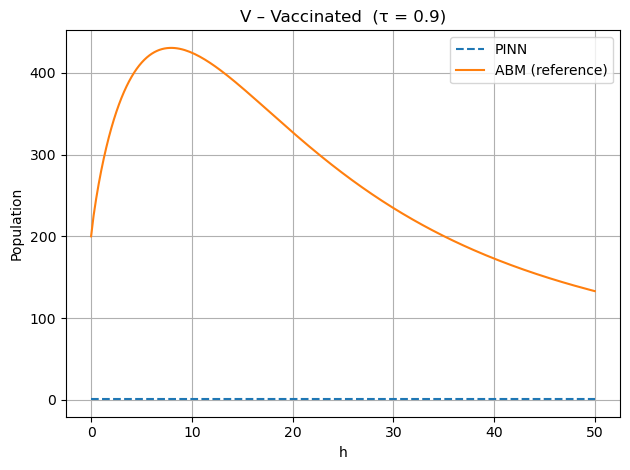

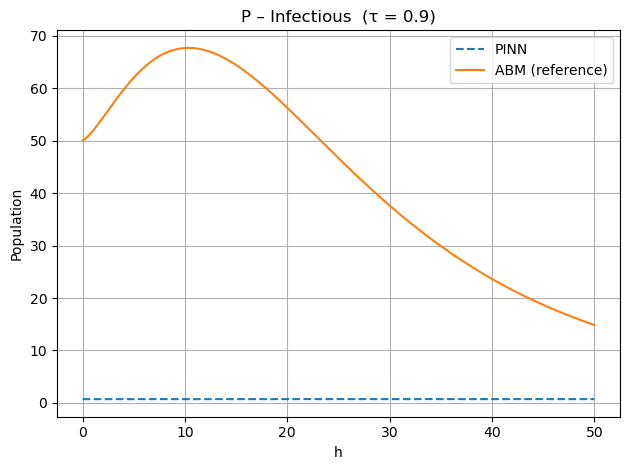

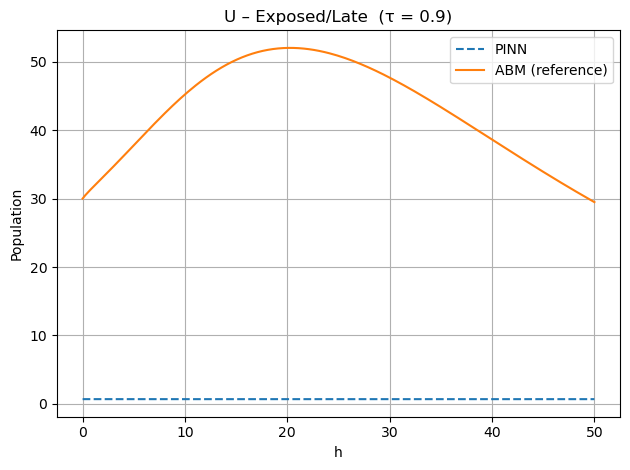

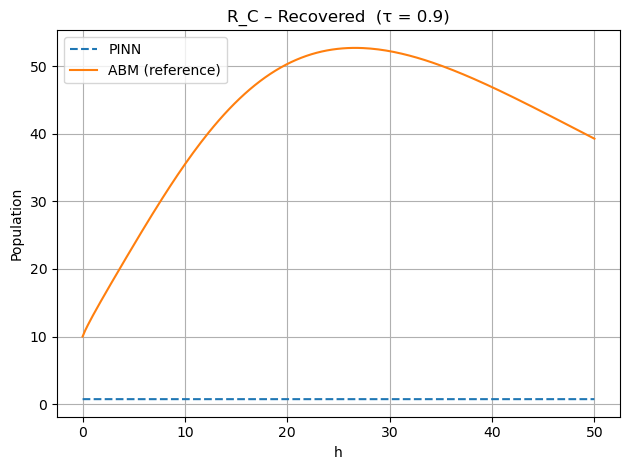

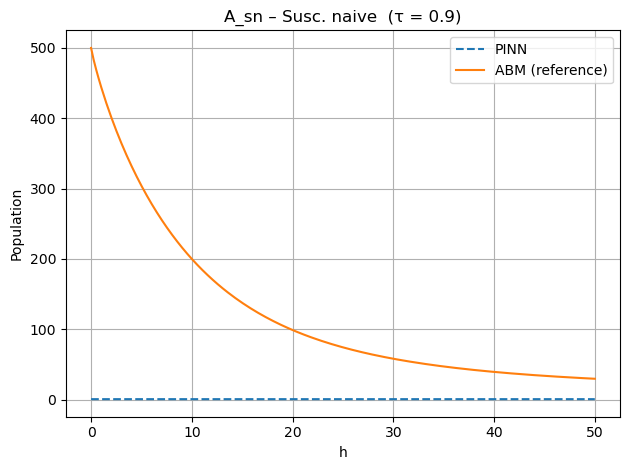

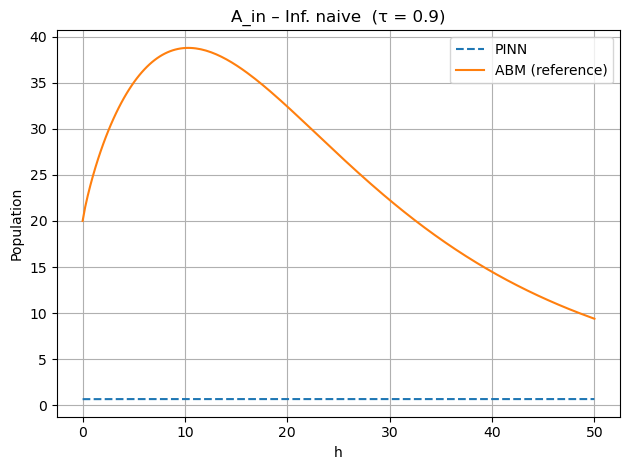

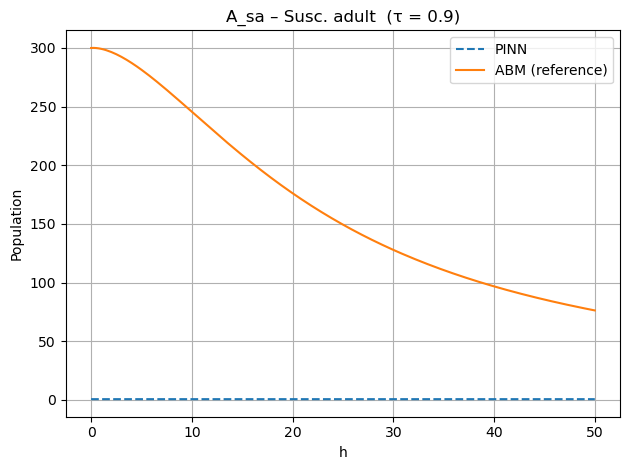

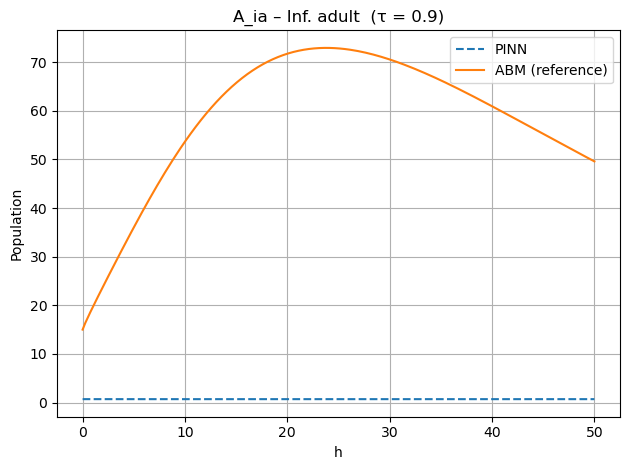

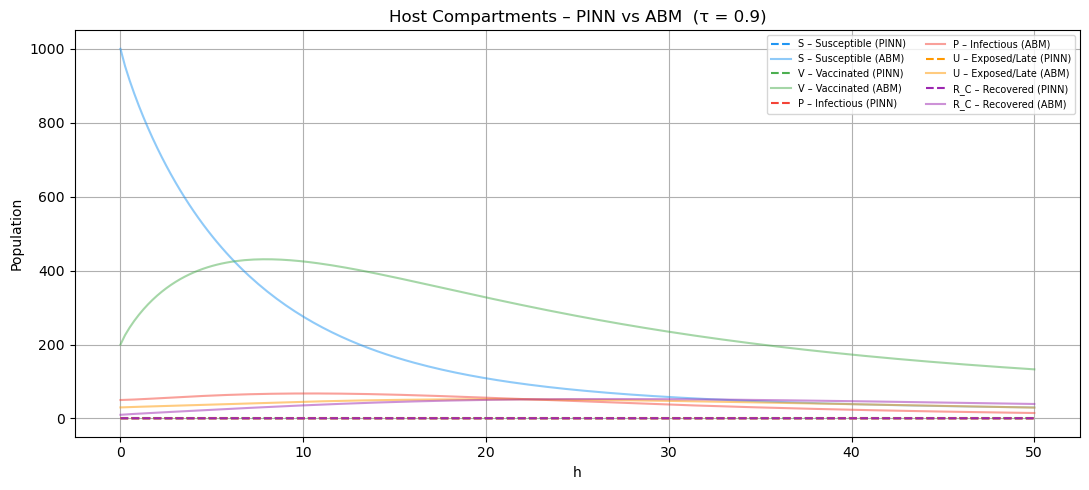

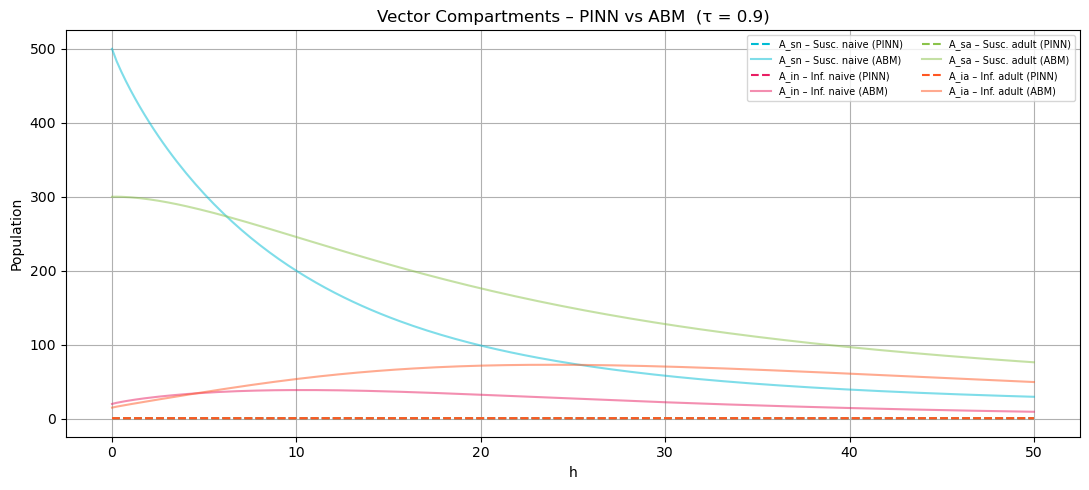

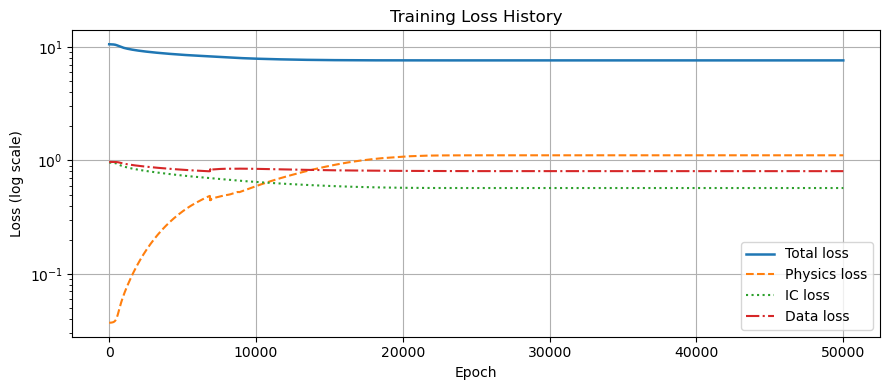

In [ ]:
########################################
# 13. INDIVIDUAL PLOTS – HOST
########################################

host_pinn = [S_p,  V_p,  P_p,  U_p,  RC_p]
host_ref  = [S_r,  V_r,  P_r,  U_r,  RC_r]
host_lbl  = ["S – Susceptible", "V – Vaccinated",
             "P – Infectious",  "U – Exposed/Late", "R_C – Recovered"]

for pinn, ref, lbl in zip(host_pinn, host_ref, host_lbl):
    plt.figure()
    plt.plot(t_np, pinn, '--', label="PINN")
    plt.plot(t_np, ref,       label="ABM (reference)")
    plt.title(f"{lbl}  (τ = {tau})")
    plt.xlabel("h"); plt.ylabel("Population")
    plt.legend(); plt.grid()
    plt.tight_layout()
    plt.show()

########################################
# 14. INDIVIDUAL PLOTS – VECTOR
########################################

vec_pinn = [Asn_p, Ain_p, Asa_p, Aia_p]
vec_ref  = [Asn_r, Ain_r, Asa_r, Aia_r]
vec_lbl  = ["A_sn – Susc. naive", "A_in – Inf. naive",
            "A_sa – Susc. adult", "A_ia – Inf. adult"]

for pinn, ref, lbl in zip(vec_pinn, vec_ref, vec_lbl):
    plt.figure()
    plt.plot(t_np, pinn, '--', label="PINN")
    plt.plot(t_np, ref,       label="ABM (reference)")
    plt.title(f"{lbl}  (τ = {tau})")
    plt.xlabel("h"); plt.ylabel("Population")
    plt.legend(); plt.grid()
    plt.tight_layout()
    plt.show()

########################################
# 15. COMBINED PLOT – HOST
########################################

colors = ["#2196F3","#4CAF50","#F44336","#FF9800","#9C27B0"]

plt.figure(figsize=(11, 5))
for i, (pinn, ref, lbl, col) in enumerate(
        zip(host_pinn, host_ref, host_lbl, colors)):
    plt.plot(t_np, pinn, '--', color=col, label=f"{lbl} (PINN)")
    plt.plot(t_np, ref,        color=col, label=f"{lbl} (ABM)", alpha=0.5)
plt.title(f"Host Compartments – PINN vs ABM  (τ = {tau})")
plt.xlabel("h"); plt.ylabel("Population")
plt.legend(fontsize=7, ncol=2); plt.grid()
plt.tight_layout()
plt.show()

########################################
# 16. COMBINED PLOT – VECTOR
########################################

colors_v = ["#00BCD4","#E91E63","#8BC34A","#FF5722"]

plt.figure(figsize=(11, 5))
for i, (pinn, ref, lbl, col) in enumerate(
        zip(vec_pinn, vec_ref, vec_lbl, colors_v)):
    plt.plot(t_np, pinn, '--', color=col, label=f"{lbl} (PINN)")
    plt.plot(t_np, ref,        color=col, label=f"{lbl} (ABM)", alpha=0.5)
plt.title(f"Vector Compartments – PINN vs ABM  (τ = {tau})")
plt.xlabel("h"); plt.ylabel("Population")
plt.legend(fontsize=7, ncol=2); plt.grid()
plt.tight_layout()
plt.show()

########################################
# 17. LOSS PLOT
########################################

plt.figure(figsize=(9, 4))
plt.semilogy(loss_history, label="Total loss",   lw=1.8)
plt.semilogy(loss_phys_h,  label="Physics loss", lw=1.5, linestyle="--")
plt.semilogy(loss_ic_h,    label="IC loss",      lw=1.5, linestyle=":")
plt.semilogy(loss_data_h,  label="Data loss",    lw=1.5, linestyle="-.")
plt.title("Training Loss History")
plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.legend(); plt.grid()
plt.tight_layout()
plt.show()